In [1]:
!pip install torch torchvision matplotlib

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

In [3]:
class PrunableLinear(nn.Module):
    def __init__(self, in_features, out_features):
        super().__init__()

        self.weight = nn.Parameter(torch.randn(out_features, in_features))
        self.bias = nn.Parameter(torch.zeros(out_features))

        self.gate_scores = nn.Parameter(torch.randn(out_features, in_features))

    def forward(self, x):
        gates = torch.sigmoid(self.gate_scores)
        pruned_weights = self.weight * gates
        return torch.nn.functional.linear(x, pruned_weights, self.bias)

In [4]:
class Net(nn.Module):
    def __init__(self):
        super().__init__()

        self.fc1 = PrunableLinear(32*32*3, 256)
        self.fc2 = PrunableLinear(256, 128)
        self.fc3 = PrunableLinear(128, 10)

    def forward(self, x):
        x = x.view(x.size(0), -1)
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        x = self.fc3(x)
        return x

In [5]:
transform = transforms.ToTensor()

train_data = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
test_data = datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
test_loader = DataLoader(test_data, batch_size=64)

100%|██████████| 170M/170M [00:02<00:00, 78.8MB/s]


In [7]:
def sparsity_loss(model):
    loss = 0
    for module in model.modules():
        if isinstance(module, PrunableLinear):
            gates = torch.sigmoid(module.gate_scores)
            loss += torch.sum(gates)
    return loss

In [9]:
def train(model, loader, lambda_val):
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    criterion = nn.CrossEntropyLoss()

    model.train()

    for epoch in range(10):
        for images, labels in loader:
            optimizer.zero_grad()

            outputs = model(images)
            cls_loss = criterion(outputs, labels)
            sp_loss = sparsity_loss(model)

            loss = cls_loss + lambda_val * sp_loss
            loss.backward()
            optimizer.step()

In [10]:
def test(model, loader):
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    return 100 * correct / total

In [14]:
def compute_sparsity(model):
    total = 0
    zero = 0

    for module in model.modules():
        if isinstance(module, PrunableLinear):
            gates = torch.sigmoid(5 * module.gate_scores)  # FIX HERE
            total += gates.numel()
            zero += (gates < 1e-2).sum().item()

    return 100 * zero / total

In [15]:
lambdas = [0.01, 0.1, 0.5]

for l in lambdas:
    print(f"\nRunning for lambda = {l}")

    model = Net()
    train(model, train_loader, l)

    acc = test(model, test_loader)
    sparsity = compute_sparsity(model)

    print(f"Accuracy: {acc:.2f}%")
    print(f"Sparsity: {sparsity:.2f}%")


Running for lambda = 0.01
Accuracy: 30.09%
Sparsity: 95.78%

Running for lambda = 0.1
Accuracy: 30.43%
Sparsity: 99.98%

Running for lambda = 0.5
Accuracy: 25.52%
Sparsity: 100.00%


In [17]:
def plot_gates(model):
    all_gates = []

    for module in model.modules():
        if isinstance(module, PrunableLinear):
            gates = torch.sigmoid(module.gate_scores).detach().cpu().numpy().flatten()
            all_gates.extend(gates)

    import matplotlib.pyplot as plt
    plt.hist(all_gates, bins=50)
    plt.title("Gate Value Distribution")
    plt.xlabel("Gate Values")
    plt.ylabel("Frequency")
    plt.show()

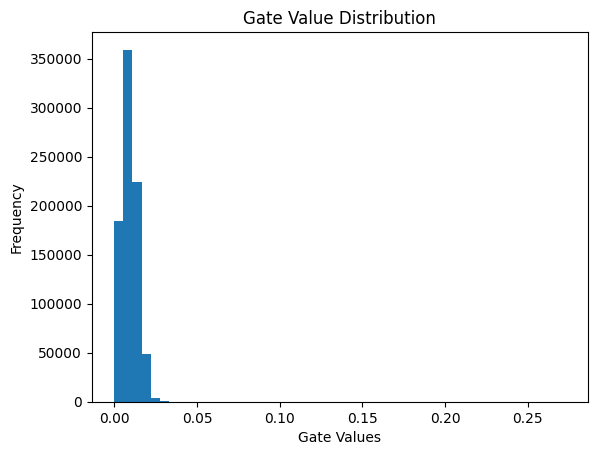

In [18]:
plot_gates(model)

In [19]:
plt.savefig("gates.png")

<Figure size 640x480 with 0 Axes>